##Let's built a micrograd that would perform gradient descent

###Functions required by a basic micrograd class:
- Initializer function
- addition function
- radd function
- multiplication function
- rmul function
- tanh activation function (you can keep adding other activation functions)
- trudiv function
- subtraction function
- negation function
- power function
- exponential function
- the original  backward function with topological sort
- let's not forget to add a repr function for string display

The functions may not necessarily occur in the same order



In [58]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import math
import random

%matplotlib inline

In [59]:
class Value:

    # Initializer function
    def __init__(self, data, _children = (), _op = "", label = ""):
        self. data = data
        self._prev = set(_children)
        self._op = _op
        self. label = label

        self.grad = 0
        self._backward = lambda: None

    # Repr function to display a string
    def __repr__(self) -> str:
        return f"Value({self.data})"

    # Addition function
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self,other), "+")

        def _backward():
            self.grad += 1 * out.grad
            other.grad += 1 * out.grad

        out._backward = _backward
        return out

    # Multiplication function
    def __mul__(self,other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self,other), "*")

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward
        return out

    # tanh function
    def tanh(self):
        n = self.data
        t = (math.exp(2*n)-1)/(math.exp(2*n)+1)
        out = Value(t, (self,), "tanh")

        def _backward():
            self.grad += (1-t**2) * out.grad

        out._backward = _backward
        return out

    # rmul function to deal with b*a
    def __rmul__(self,other):
        return self * other

    # radd function to deal with b+a
    def __radd__(self,other):
        return self + other

    # power function
    def __pow__(self,other):
        assert isinstance(other, (int,float))
        out = Value(self.data**other, (self,), f"**{other}")

        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad

        out._backward = _backward
        return out

    # exponential function
    def exp(self):
        n = self.data
        out = Value(math.exp(n), (self,), "exp")

        def _backward():
            self.grad += out.data * out.grad

        out._backward = _backward
        return out

    # Truediv function
    def __truediv__(self,other):
        return self * other ** -1

    # Subtraction function
    def __sub__(self, other):
        return self + (-other)

    # Negation function
    def __neg__(self):
        return self * -1

    # The actual backward function
    def backward(self):
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)

                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)
        self.grad = 1.0

        for node in reversed(topo):
            node._backward()


# Now let's build a Neural Network from scratch

It will require three classes:
- Neuron class
- Layer class
- MLP class

In [60]:
class Neuron:

    def __init__(self,nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self,x):
        # sum(wi*xi) + b
        act = sum((wi*xi for wi, xi in zip(self.w, x)), 0.0) + self.b
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]

class Layer:

    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self,x):
        return [neuron(x) for neuron in self.neurons]

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:

    def __init__(self,nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self,x):
        for layer in self.layers:
            x= layer(x)
        return x[0] if len(x) == 1 else x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

# MSE Loss function

In [61]:
# creating an instance of the MLP class
n = MLP(3, [4, 4, 1])

In [62]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets
ypred = [n(x) for x in xs]
ypred

[Value(0.8199758507695278),
 Value(0.4809781860171089),
 Value(0.9298765180712948),
 Value(0.7688376848144752)]

In [71]:
# defining the MSE loss function
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))/ len(ys)

In [72]:
# Propagating the loss via gradient descent
loss.backward()

# Using a pre-built code for computational graph visualization

In [65]:
# This is a pre-built code to visualize the graph of the operations happening

from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

--- Computation Graph for Input 0: [2.0, 3.0, -1.0] ---


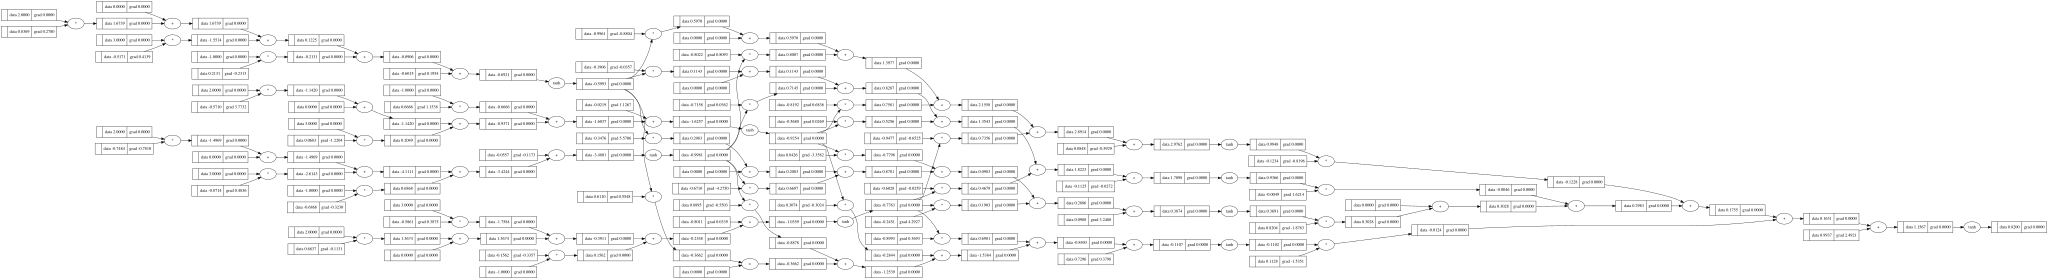

--- Computation Graph for Input 1: [3.0, -1.0, 0.5] ---


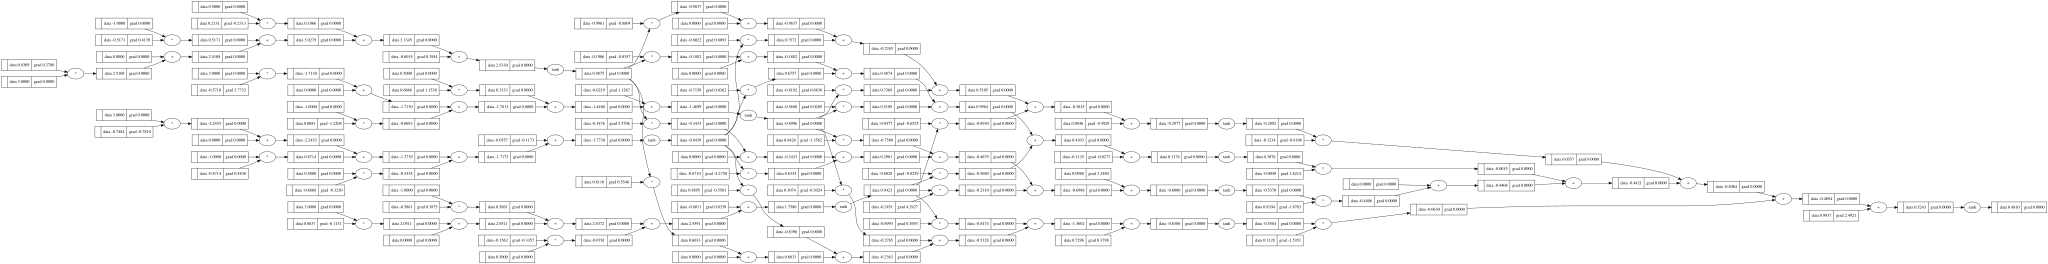

--- Computation Graph for Input 2: [0.5, 1.0, 1.0] ---


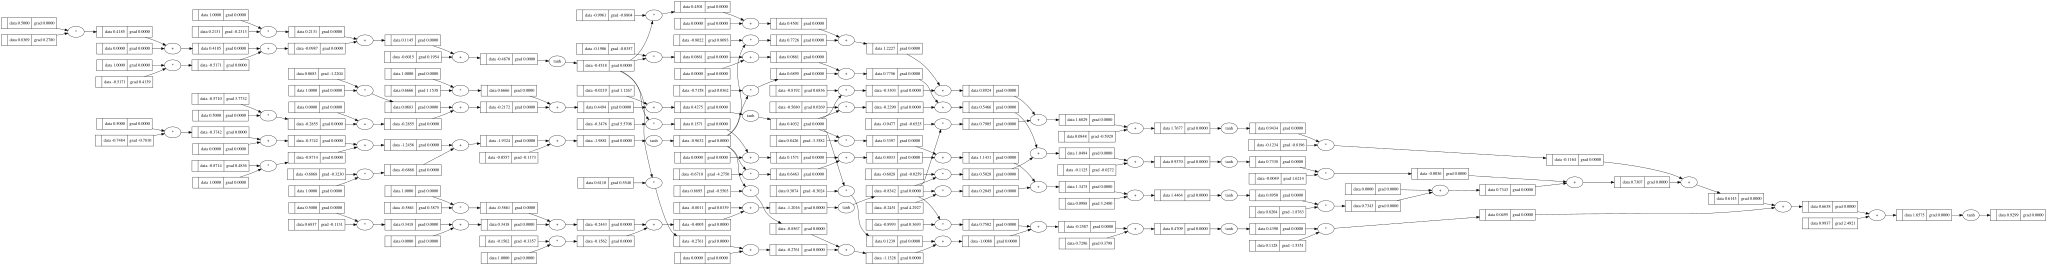

--- Computation Graph for Input 3: [1.0, 1.0, -1.0] ---


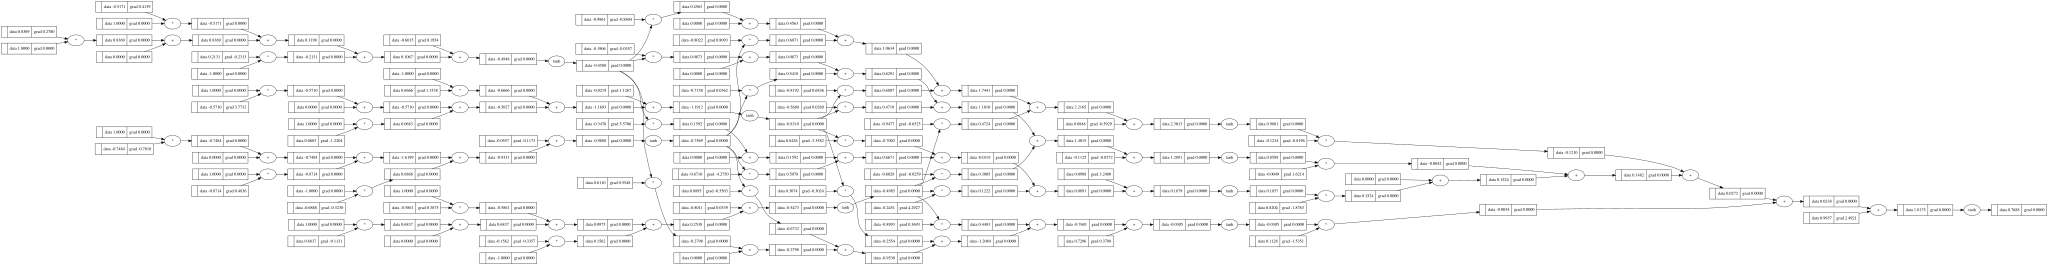

In [73]:
for i, x in enumerate(xs):
    print(f"--- Computation Graph for Input {i}: {x} ---")
    y_out = n(x)
    display(draw_dot(y_out))